In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
data = pd.read_csv('../datasets/PJME_preprocessd.csv',parse_dates=['Datetime'],index_col='Datetime')
print(data.shape)
data.head()

(145224, 15)


,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,0.433011,1,8,2,1,1,0,31187.0,26862.0,27100.0,30393.0,33560.208333,4425.965952,32513.869048
2002-01-08 02:00:00,28670.0,0.409021,2,8,2,1,1,0,29445.0,25976.0,26097.0,29265.0,33672.458333,4256.159403,32510.327381
2002-01-08 03:00:00,28375.0,0.399889,3,8,2,1,1,0,28670.0,25641.0,25793.0,28357.0,33786.375000,4064.104959,32510.434524
2002-01-08 04:00:00,28542.0,0.405058,4,8,2,1,1,0,28375.0,25666.0,25657.0,27899.0,33906.208333,3851.076461,32514.261905
2002-01-08 05:00:00,29261.0,0.427316,5,8,2,1,1,0,28542.0,26328.0,25778.0,28057.0,34028.416667,3640.941409,32521.428571


In [3]:
print(data.info())
print(data.columns)
print(data.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 145224 entries, 2002-01-08 01:00:00 to 2018-08-03 00:00:00
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   PJME_MW          145224 non-null  float64
 1   PJME_MW_Scaled   145224 non-null  float64
 2   Hour             145224 non-null  int64  
 3   Day              145224 non-null  int64  
 4   Week             145224 non-null  int64  
 5   Month            145224 non-null  int64  
 6   DayOfWeek        145224 non-null  int64  
 7   Weekend          145224 non-null  int64  
 8   Lag_1            145224 non-null  float64
 9   Lag_24           145224 non-null  float64
 10  Lag_48           145224 non-null  float64
 11  Lag_168          145224 non-null  float64
 12  RollingMean_24   145224 non-null  float64
 13  RollingStd_24    145224 non-null  float64
 14  RollingMean_168  145224 non-null  float64
dtypes: float64(9), int64(6)
memory usage: 17.7 MB
None
Index(['PJM

In [4]:
print(data.isnull().sum())

PJME_MW            0
PJME_MW_Scaled     0
Hour               0
Day                0
Week               0
Month              0
DayOfWeek          0
Weekend            0
Lag_1              0
Lag_24             0
Lag_48             0
Lag_168            0
RollingMean_24     0
RollingStd_24      0
RollingMean_168    0
dtype: int64


In [5]:
print('Start date:', data.index.min())
print('End date  :', data.index.max())
print('Total rows:', len(data))

Start date: 2002-01-08 01:00:00
End date  : 2018-08-03 00:00:00
Total rows: 145224


In [7]:
from tensorflow.keras.models import load_model

# Load the saved baseline Bi-LSTM model
best_model = load_model('../bilstm168_phase6_baseline.keras')

print('Baseline Bi-LSTM model loaded successfully.')

Baseline Bi-LSTM model loaded successfully.


E0000 00:00:1786516066.322269  344672 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

features = [
    'PJME_MW_Scaled',
    'Hour',
    'Day',
    'Week',
    'Month',
    'DayOfWeek',
    'Weekend',
    'Lag_1',
    'Lag_24',
    'Lag_48',
    'Lag_168',
    'RollingMean_24',
    'RollingStd_24',
    'RollingMean_168'
]

target = 'PJME_MW_Scaled'

sequence_length = 168
forecast_horizon = 24


In [12]:

total_rows = len(data)
test_size = int(total_rows * 0.20)

# Test set (final 20%)
test_data = data.iloc[-test_size:]

# Remaining 80%
remaining_data = data.iloc[:-test_size]

# Last timestamp in remaining data
validation_end = remaining_data.index.max()

# Validation starts 60 days before the end
validation_start = validation_end - pd.Timedelta(days=60) + pd.Timedelta(hours=1)

# Validation set
validation_data = remaining_data.loc[validation_start:validation_end]

# Training set (everything before validation)
train_data = remaining_data.loc[:validation_start - pd.Timedelta(hours=1)]

print('Train shape      :', train_data.shape)
print('Validation shape :', validation_data.shape)
print('Test shape       :', test_data.shape)

print(train_data.index.min(), '->', train_data.index.max())
print(validation_data.index.min(), '->', validation_data.index.max())
print(test_data.index.min(), '->', test_data.index.max())

Train shape      : (114740, 15)
Validation shape : (1440, 15)
Test shape       : (29044, 15)
2002-01-08 01:00:00 -> 2015-02-09 20:00:00
2015-02-09 21:00:00 -> 2015-04-10 20:00:00
2015-04-10 21:00:00 -> 2018-08-03 00:00:00


In [13]:
from sklearn.preprocessing import MinMaxScaler

features = [
    'PJME_MW_Scaled',
    'Hour',
    'Day',
    'Week',
    'Month',
    'DayOfWeek',
    'Weekend',
    'Lag_1',
    'Lag_24',
    'Lag_48',
    'Lag_168',
    'RollingMean_24',
    'RollingStd_24',
    'RollingMean_168'
]

target = 'PJME_MW_Scaled'

feature_scaler = MinMaxScaler()
feature_scaler.fit(train_data[features])

validation_scaled = pd.DataFrame(
    feature_scaler.transform(validation_data[features]),
    columns=features,
    index=validation_data.index
)

validation_scaled.head()

,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,
2015-02-09 21:00:00,0.741363,0.913043,0.266667,0.115385,0.090909,0.000000,0.0,0.773929,0.559435,0.579371,0.815131,0.572622,0.466744,0.572705
2015-02-09 22:00:00,0.684776,0.956522,0.266667,0.115385,0.090909,0.000000,0.0,0.741363,0.518512,0.549034,0.765076,0.581108,0.468180,0.571908
2015-02-09 23:00:00,0.606334,1.000000,0.266667,0.115385,0.090909,0.000000,0.0,0.684776,0.465856,0.503622,0.690534,0.588278,0.457935,0.571072
2015-02-10 00:00:00,0.536992,0.000000,0.300000,0.115385,0.090909,0.166667,0.0,0.606334,0.410816,0.452390,0.626145,0.594718,0.438573,0.570187
2015-02-10 01:00:00,0.492787,0.043478,0.300000,0.115385,0.090909,0.166667,0.0,0.536992,0.370233,0.408154,0.585841,0.600973,0.411985,0.569263


In [14]:
sequence_length = 168
forecast_horizon = 24

X_val_phase7 = []
y_val_phase7 = []

values = validation_scaled.values
target_values = validation_scaled[target].values

for i in range(len(values) - sequence_length - forecast_horizon + 1):
    X_val_phase7.append(values[i:i + sequence_length])
    y_val_phase7.append(
        target_values[
            i + sequence_length :
            i + sequence_length + forecast_horizon
        ]
    )

X_val_phase7 = np.array(X_val_phase7)
y_val_phase7 = np.array(y_val_phase7)

print(X_val_phase7.shape)
print(y_val_phase7.shape)

(1249, 168, 14)
(1249, 24)


In [16]:
from sklearn.preprocessing import MinMaxScaler

# Recreate the target scaler
scaler = MinMaxScaler()
scaler.fit(data[['PJME_MW']])

print('Target scaler recreated successfully.')

Target scaler recreated successfully.


In [17]:

pred_list = []
actual_list = []

for i in range(0, len(X_val_phase7), 24):

    pred = best_model.predict(
        X_val_phase7[i:i+1],
        verbose=0
    )

    pred_original = scaler.inverse_transform(
        pred.reshape(-1, 1)
    ).flatten()

    actual_original = scaler.inverse_transform(
        y_val_phase7[i].reshape(-1, 1)
    ).flatten()

    pred_list.extend(pred_original)
    actual_list.extend(actual_original)

pred_series = np.array(pred_list)
actual_series = np.array(actual_list)

print('Prediction series shape:', pred_series.shape)
print('Actual series shape    :', actual_series.shape)

Prediction series shape: (1272,)
Actual series shape    : (1272,)


In [20]:
hours_30 = 30 * 24

actual_30 = actual_series[:hours_30]
pred_30 = pred_series[:hours_30]

mae_30 = mean_absolute_error(actual_30, pred_30)
mse_30 = mean_squared_error(actual_30, pred_30)
rmse_30 = np.sqrt(mse_30)
mape_30 = mean_absolute_percentage_error(actual_30, pred_30) * 100
r2_30 = r2_score(actual_30, pred_30)
bias_30 = np.mean(pred_30 - actual_30)

In [22]:
mae_60 = mean_absolute_error(actual_series, pred_series)
mse_60 = mean_squared_error(actual_series, pred_series)
rmse_60 = np.sqrt(mse_60)
mape_60 = mean_absolute_percentage_error(actual_series, pred_series) * 100
r2_60 = r2_score(actual_series, pred_series)
bias_60 = np.mean(pred_series - actual_series)

In [23]:
phase7_metrics = pd.DataFrame([
    {
        'Validation Period': '30 Days',
        'MAE': mae_30,
        'MSE': mse_30,
        'RMSE': rmse_30,
        'MAPE': mape_30,
        'R2': r2_30,
        'Bias': bias_30
    },
    {
        'Validation Period': '60 Days',
        'MAE': mae_60,
        'MSE': mse_60,
        'RMSE': rmse_60,
        'MAPE': mape_60,
        'R2': r2_60,
        'Bias': bias_60
    }
])

phase7_metrics

,Validation Period,MAE,MSE,RMSE,MAPE,R2,Bias
0,30 Days,1658.169797,4.588207e+06,2142.010004,4.731864,0.829505,128.474582
1,60 Days,1428.190092,3.535180e+06,1880.207311,4.356021,0.876965,217.252994


In [24]:
phase7_metrics.to_csv(
    '../phase7_validation_metrics.csv',
    index=False
)

print('Phase 7 validation metrics saved successfully.')

Phase 7 validation metrics saved successfully.


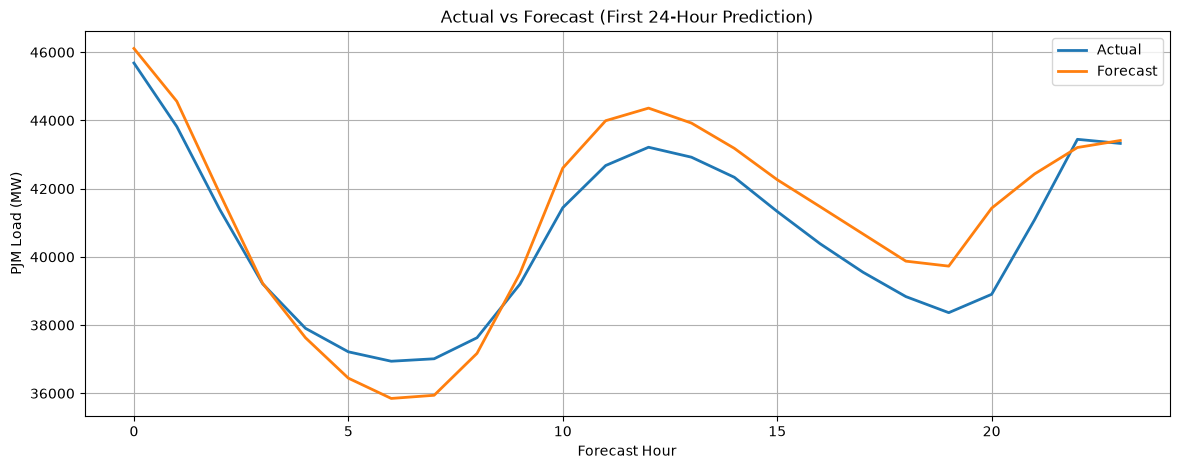

Actual vs Forecast 24-hour validation plot saved successfully.


In [39]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Actual vs Forecast - First 24-Hour Prediction
# ---------------------------------------------------

val_actual_original = actual_series[:24]
val_pred_original = pred_series[:24]

plt.figure(figsize=(14, 5))

plt.plot(
    val_actual_original,
    label='Actual',
    linewidth=2
)

plt.plot(
    val_pred_original,
    label='Forecast',
    linewidth=2
)

plt.title('Actual vs Forecast (First 24-Hour Prediction)')
plt.xlabel('Forecast Hour')
plt.ylabel('PJM Load (MW)')
plt.legend()
plt.grid(True)

plt.savefig(
    '../actual_vs_forecast_24h.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Actual vs Forecast 24-hour validation plot saved successfully.')

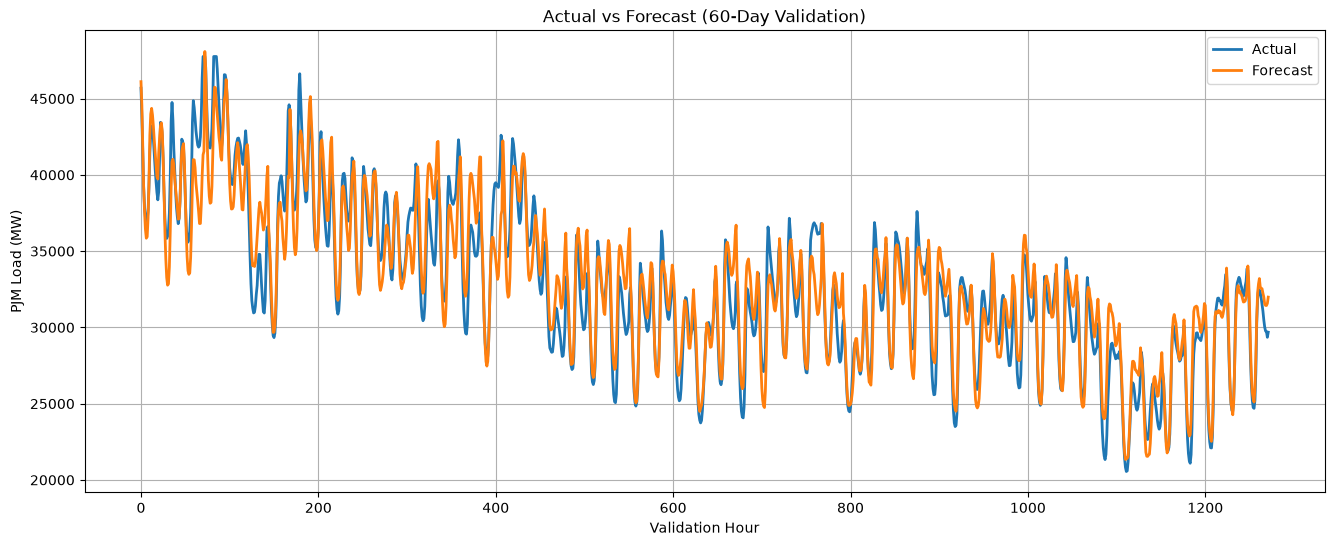

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(actual_series, label='Actual', linewidth=2)
plt.plot(pred_series, label='Forecast', linewidth=2)

plt.title('Actual vs Forecast (60-Day Validation)')
plt.xlabel('Validation Hour')
plt.ylabel('PJM Load (MW)')
plt.legend()
plt.grid(True)
plt.savefig('../actual_vs_forecast_validation.png',dpi=300,bbox_inches='tight')
plt.show()



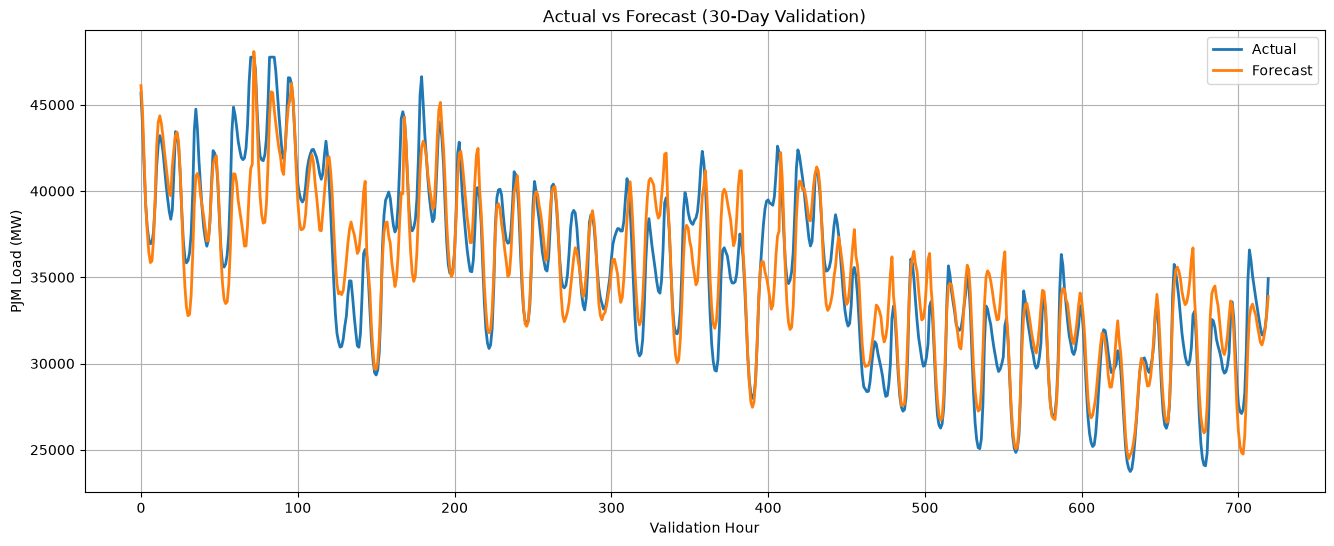

30-Day Forecast Performance validation plot saved successfully.


In [29]:

plt.figure(figsize=(16, 6))
plt.plot(actual_30, label='Actual', linewidth=2)
plt.plot(pred_30, label='Forecast', linewidth=2)
plt.title('Actual vs Forecast (30-Day Validation)')
plt.xlabel('Validation Hour')
plt.ylabel('PJM Load (MW)')
plt.legend()
plt.grid(True)

plt.savefig(
    '../actual_vs_forecast_30day_validation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('30-Day Forecast Performance validation plot saved successfully.')

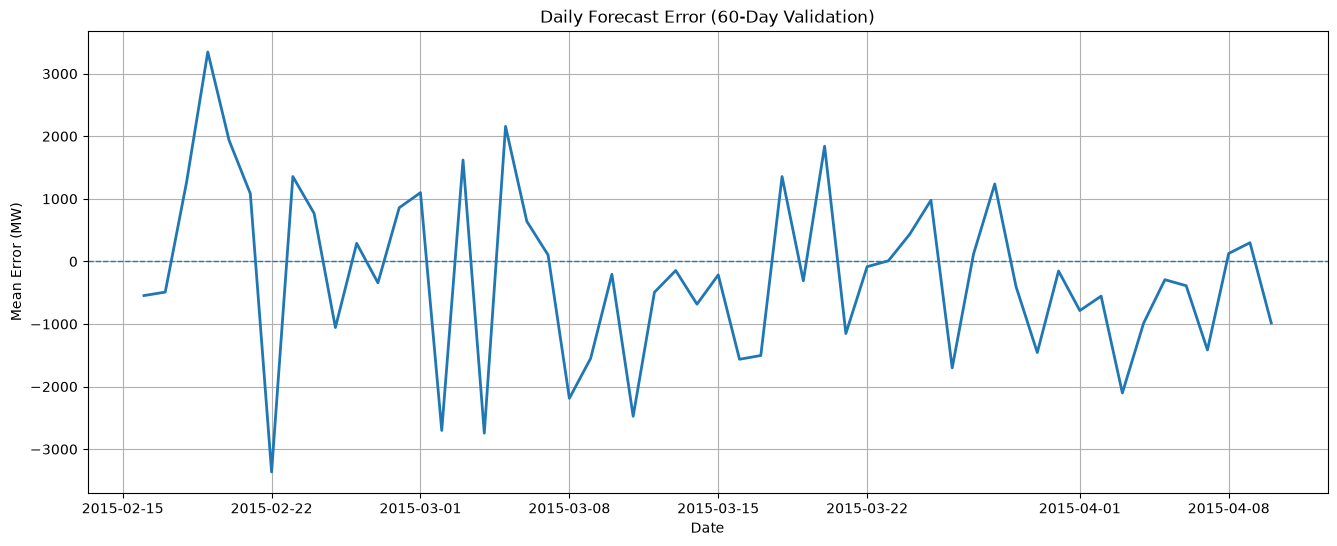

In [34]:
validation_df = pd.DataFrame({
    'Actual': actual_series,
    'Forecast': pred_series
})

validation_df.index = pd.date_range(
    start=validation_data.index[sequence_length],
    periods=len(validation_df),
    freq='h'
)

validation_df['Error'] = (
    validation_df['Actual'] -
    validation_df['Forecast']
)
daily_error = validation_df['Error'].resample('D').mean()

plt.figure(figsize=(16, 6))

plt.plot(
    daily_error.index,
    daily_error.values,
    linewidth=2
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.title('Daily Forecast Error (60-Day Validation)')
plt.xlabel('Date')
plt.ylabel('Mean Error (MW)')
plt.grid(True)

plt.savefig(
    '../daily_error_validation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

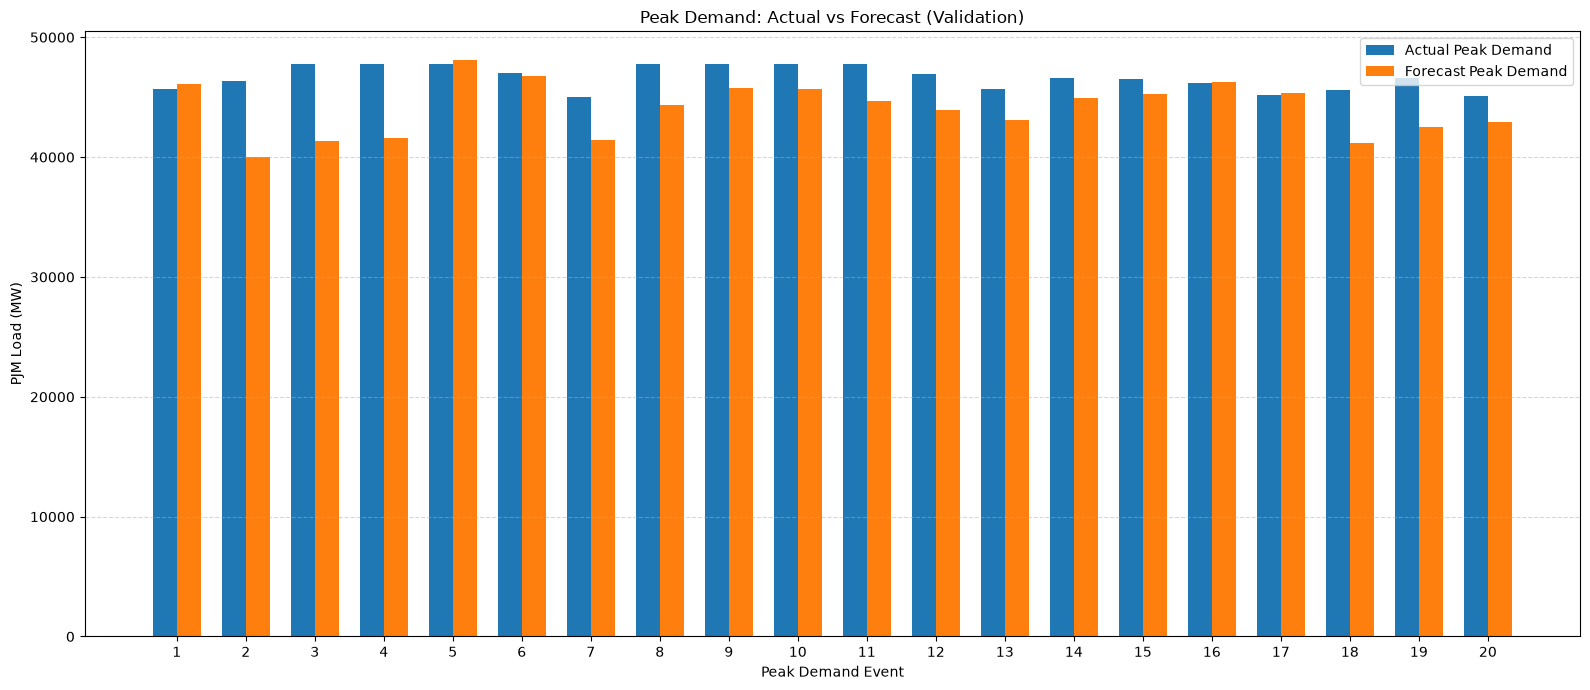

Peak Demand validation plot saved successfully.


In [40]:
# Find top 20 actual demand values
peak_indices = np.argsort(actual_series)[-20:]

# Sort them chronologically
peak_indices = np.sort(peak_indices)

peak_actual = actual_series[peak_indices]
peak_forecast = pred_series[peak_indices]

# Create event numbers
peak_events = np.arange(1, len(peak_indices) + 1)

plt.figure(figsize=(16, 7))

# Bar width
width = 0.35

plt.bar(
    peak_events - width/2,
    peak_actual,
    width=width,
    label='Actual Peak Demand'
)

plt.bar(
    peak_events + width/2,
    peak_forecast,
    width=width,
    label='Forecast Peak Demand'
)

plt.title('Peak Demand: Actual vs Forecast (Validation)')
plt.xlabel('Peak Demand Event')
plt.ylabel('PJM Load (MW)')
plt.xticks(peak_events)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig(
    '../peak_demand_error_validation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Peak Demand validation plot saved successfully.')

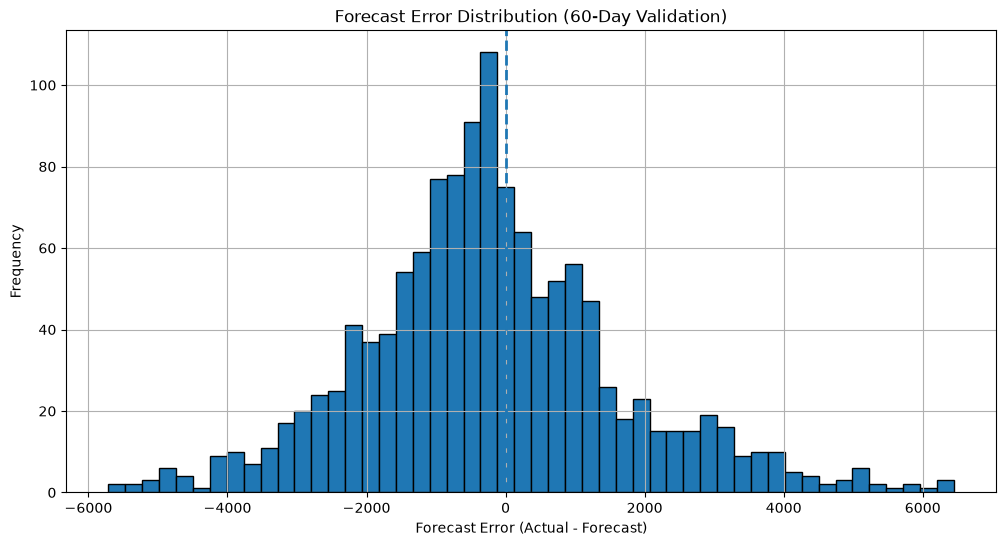

Forecast Error Distribution validation plot saved successfully.


In [37]:
#--------------------------------------------------
# Forecast Error Distribution - 60 Day Validation
# ---------------------------------------------------

errors = (
    validation_df['Actual'] -
    validation_df['Forecast']
)

plt.figure(figsize=(12, 6))

plt.hist(
    errors,
    bins=50,
    edgecolor='black'
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=2
)

plt.title('Forecast Error Distribution (60-Day Validation)')
plt.xlabel('Forecast Error (Actual - Forecast)')
plt.ylabel('Frequency')
plt.grid(True)

plt.savefig(
    '../forecast_error_distribution_validation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Forecast Error Distribution validation plot saved successfully.')